# Extração

In [2]:
import pandas as pd
import numpy as np

In [3]:
import pandas as pd
import requests

url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'


dados = pd.read_json(url)

dados.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:

customer = pd.json_normalize(dados['customer'])
phone = pd.json_normalize(dados['phone'])
internet = pd.json_normalize(dados['internet'])
account = pd.json_normalize(dados['account'])


dados_final = pd.concat([
    dados[['customerID', 'Churn']],
    customer,
    phone,
    internet,
    account
], axis=1)


dados_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# Transformação

In [5]:
print(dados_final.isna().sum())

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [6]:
# dados_final.duplicated().sum()
print(dados_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [7]:
dados_final['Charges.Total'] = pd.to_numeric(dados_final['Charges.Total'], errors='coerce')

In [8]:
dados_final['Charges.Total'] = dados_final['Charges.Total'].fillna(0)

In [9]:
dados_final['Contas_Diarias'] = np.where(
    dados_final['tenure'] > 0,
    dados_final['Charges.Total'] / dados_final['tenure'],
    0
)

dados_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,65.922222
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,60.266667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,70.212500
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,95.219231
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,89.133333


In [10]:
dados_final.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Contas_Diarias'],
      dtype='object')

In [11]:
mapeamento = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}


colunas_para_binario = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

dados_final[colunas_para_binario] = dados_final[colunas_para_binario].replace(mapeamento)


dados_final[colunas_para_binario].head()

/tmp/ipykernel_330/3932927494.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados_final[colunas_para_binario] = dados_final[colunas_para_binario].replace(mapeamento)


,Churn,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,1,1,1
1,0,0,0,1,0
2,1,0,0,1,1
3,1,1,0,1,1
4,1,1,0,1,1


# Carga e Analise

In [12]:
dados_final.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Contas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2277.182035,64.658892
std,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.648587,30.305125
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,396.200000,35.465000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1389.200000,70.228070
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3778.525000,90.174158
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,121.400000


In [13]:

resumo_numerico = dados_final.describe()
print("Análise Descritiva - Numérica:")
display(resumo_numerico)

Análise Descritiva - Numérica:


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Contas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2277.182035,64.658892
std,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.648587,30.305125
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,396.200000,35.465000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1389.200000,70.228070
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3778.525000,90.174158
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,121.400000


In [14]:

dados_final['Churn'] = dados_final['Churn'].astype(str).replace({
    'Yes': '1',
    'No': '0',
    '1': '1',
    '0': '0',
    'True': '1',
    'False': '0'
})


dados_final['Churn'] = pd.to_numeric(dados_final['Churn'], errors='coerce')

dados_final['tenure'] = pd.to_numeric(dados_final['tenure'], errors='coerce')

dados_final.dropna(subset=['Churn', 'tenure'], inplace=True)

dados_final['Churn'] = dados_final['Churn'].astype(int)
dados_final['tenure'] = dados_final['tenure'].astype(int)

print(f"Taxa de Churn: {dados_final['Churn'].mean() * 100:.2f}%")
print(f"Tempo médio: {dados_final['tenure'].mean():.1f} meses")

Taxa de Churn: 26.54%
Tempo médio: 32.4 meses


/tmp/ipykernel_330/1833327059.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=dados_final, palette='viridis')


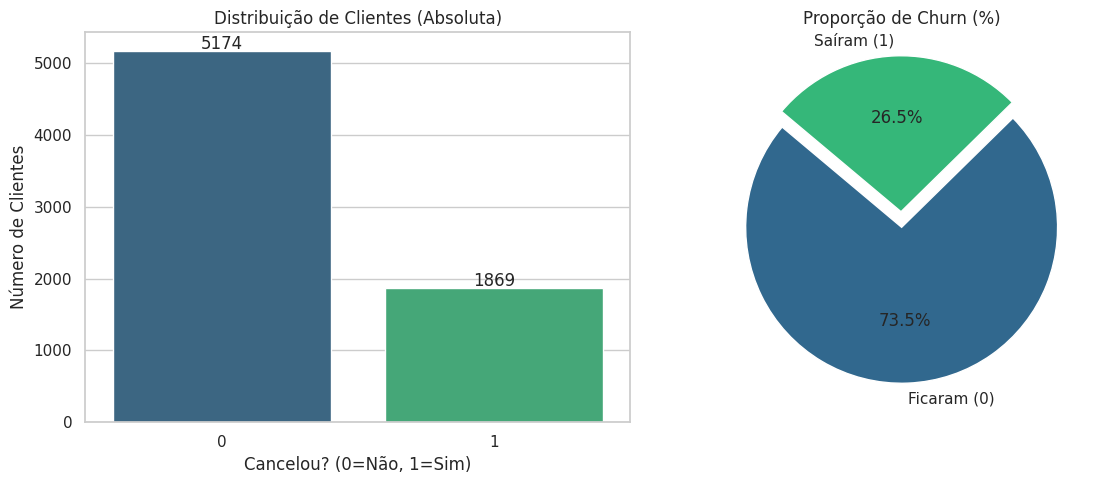

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
ax = sns.countplot(x='Churn', data=dados_final, palette='viridis')
plt.title('Distribuição de Clientes (Absoluta)')
plt.xlabel('Cancelou? (0=Não, 1=Sim)')
plt.ylabel('Número de Clientes')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points')


plt.subplot(1, 2, 2)
churn_counts = dados_final['Churn'].value_counts()
plt.pie(churn_counts, labels=['Ficaram (0)', 'Saíram (1)'], autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('viridis', 2), explode=(0, 0.1))
plt.title('Proporção de Churn (%)')

plt.tight_layout()
plt.show()

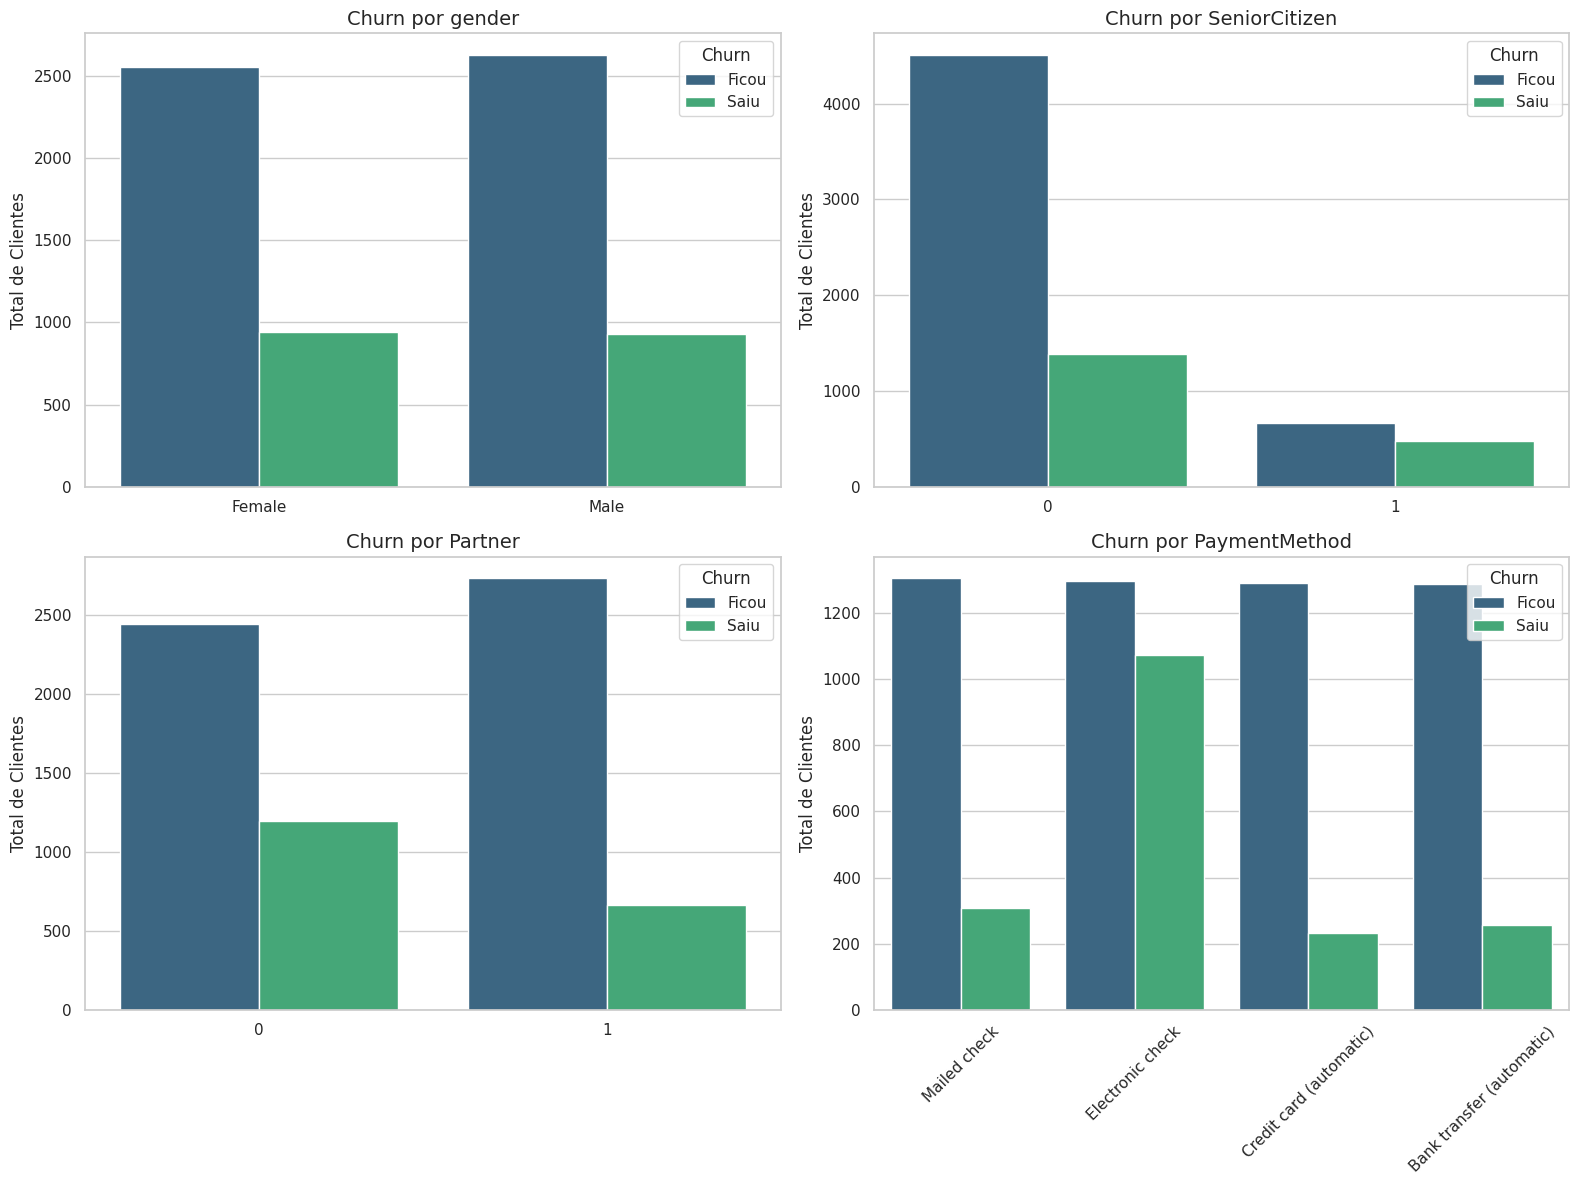

In [16]:

colunas_categoricas = ['gender', 'SeniorCitizen', 'Partner', 'PaymentMethod']


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):

    sns.countplot(x=col, hue='Churn', data=dados_final, ax=axes[i], palette='viridis')


    axes[i].set_title(f'Churn por {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Total de Clientes')
    axes[i].legend(title='Churn', labels=['Ficou', 'Saiu'])


    if col == 'PaymentMethod':
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_330/4175557783.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=dados_final, palette='Set2')


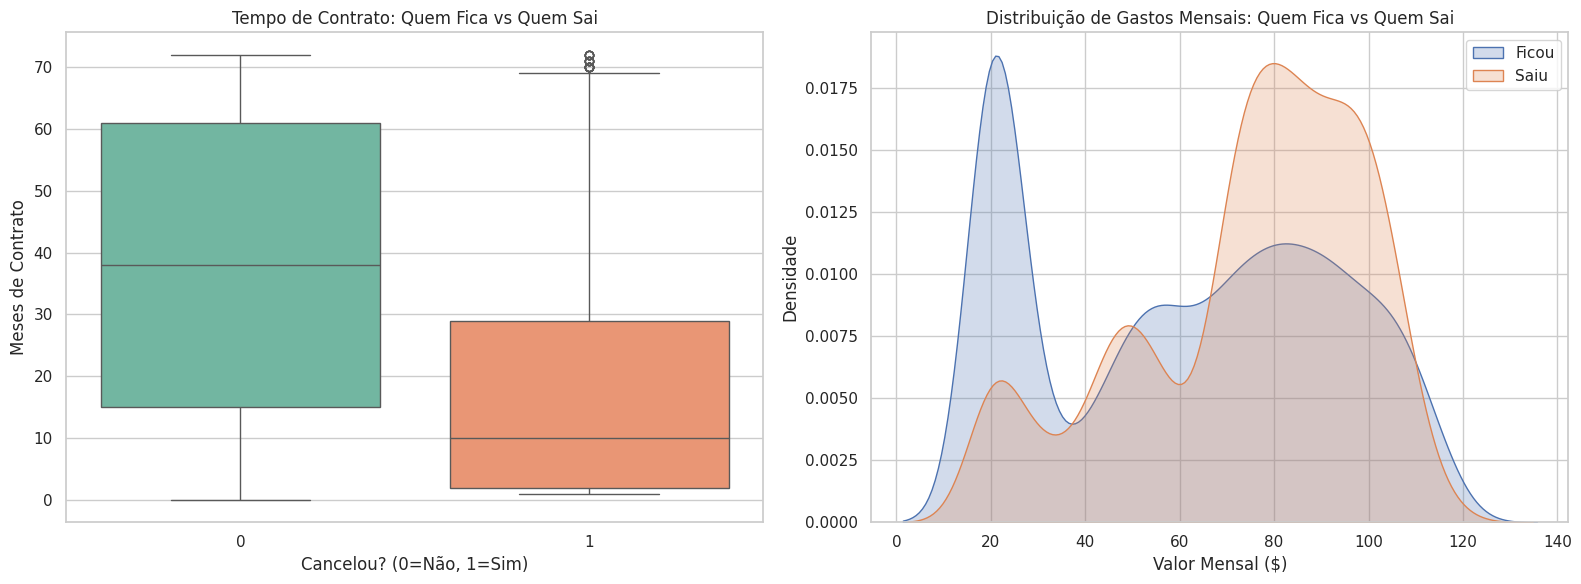

In [17]:

plt.figure(figsize=(16, 6))

# 1. Churn vs Tempo de Contrato (tenure)
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='tenure', data=dados_final, palette='Set2')
plt.title('Tempo de Contrato: Quem Fica vs Quem Sai')
plt.xlabel('Cancelou? (0=Não, 1=Sim)')
plt.ylabel('Meses de Contrato')

# 2. Churn vs Valor Mensal (MonthlyCharges)
plt.subplot(1, 2, 2)
sns.kdeplot(dados_final[dados_final['Churn'] == 0]['Charges.Monthly'], label='Ficou', fill=True)
sns.kdeplot(dados_final[dados_final['Churn'] == 1]['Charges.Monthly'], label='Saiu', fill=True)
plt.title('Distribuição de Gastos Mensais: Quem Fica vs Quem Sai')
plt.xlabel('Valor Mensal ($)')
plt.ylabel('Densidade')
plt.legend()

plt.tight_layout()
plt.show()

# Relatório

### Introdução e Limpeza

Relatório de Análise de Churn - TelecomX

O objetivo desta análise foi investigar o Churn que é a saida de clientes da TelecomX. O Churn é uma das métricas mais críticas para empresas de serviços, pois o custo de adquirir um novo cliente é geralmente muito superior ao de manter um atual.

Limpeza e Tratamento de Dados
Os dados foram extraídos diretamente de uma API em formato JSON. O processo de tratamento incluiu:

Normalização: Expansão de colunas aninhadas (customer, phone, internet, account) para um formato tabular.

Conversão de Tipos: Transformação de colunas como Charges.TOtal e tenure para formatos numéricos.

Tratamento de Dados Ausentes: Identificação de valores vazios em novos clientes, preenchidos estrategicamente com 0.

Codificação: Transformação da variável alvo Churn e outras categóricas em valores binários (0 e 1) para permitir análises matemáticas e o cálculo da taxa de evasão.

Engenharia de Dados: Criação da métrica Custo_Diario

Análise Exploratória de Dados
Durante a análise, identificamos padrões visuais claros através de gráficos:

Distribuição de Churn: A base apresenta uma taxa de evasão de aproximadamente 26.54%

Perfil de Contrato: Clientes com contratos mensais (Month-to-month) possuem uma taxa de cancelamento drasticamente superior aos contratos anuais.

Comportamento de Gastos: Clientes que cancelam tendem a ter gastos mensais mais elevados

Tempo de Casa: O risco de Churn é altíssimo nos primeiros 6 meses de contrato, diminuindo conforme o cliente ganha tempo de casa (tenure).



### COnclusão

Conclusões
O "Período Crítico": A maior parte da evasão ocorre no início da jornada do cliente.

Sensibilidade a Preço: Clientes com pacotes mais caros são mais propensos a sair, sugerindo que o valor percebido pode não estar acompanhando o custo.

Fator Técnico: Clientes de fibra óptica apresentaram padrões de saída que merecem atenção das equipes de suporte.





# Machine Learning

In [18]:

colunas_para_dropar = ['customerID']


df_analise = dados_final.drop(columns=colunas_para_dropar)


print(f"Colunas restantes: {len(df_analise.columns)}")
df_analise.head()

Colunas restantes: 21


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,65.922222
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,60.266667
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,70.212500
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,95.219231
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,89.133333


In [19]:

colunas_categoricas = df_analise.select_dtypes(include=['object']).columns.tolist()


df_final_ml = pd.get_dummies(df_analise, columns=colunas_categoricas, dtype=int)


print(f"Total de colunas após o One-Hot Encoding: {len(df_final_ml.columns)}")
df_final_ml.head()

Total de colunas após o One-Hot Encoding: 43


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Contas_Diarias,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,65.922222,...,1,0,0,0,1,0,0,0,0,1
1,0,0,0,0,9,1,0,59.9,542.40,60.266667,...,0,0,1,1,0,0,0,0,0,1
2,1,0,0,0,4,1,1,73.9,280.85,70.212500,...,1,0,0,1,0,0,0,0,1,0
3,1,1,1,0,13,1,1,98.0,1237.85,95.219231,...,0,0,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,1,83.9,267.40,89.133333,...,1,0,0,1,0,0,0,0,0,1


In [20]:

contagem_churn = dados_final['Churn'].value_counts()

proporcao_churn = dados_final['Churn'].value_counts(normalize=True) * 100

print("Contagem de Clientes:")
print(contagem_churn)

print("\nProporção de Churn:")
print(proporcao_churn)

Contagem de Clientes:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporção de Churn:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [21]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Separar as variáveis explicativas (X) do alvo (y)

X = df_final_ml.drop(columns=['Churn'])
y = df_final_ml['Churn']

print(f"Distribuição original: {Counter(y)}")

# 2. Configurar e aplicar o SMOTE
smt = SMOTE(random_state=42)
X_res, y_res = smt.fit_resample(X, y)

print(f"Distribuição após SMOTE: {Counter(y_res)}")

Distribuição original: Counter({0: 5174, 1: 1869})
Distribuição após SMOTE: Counter({0: 5174, 1: 5174})


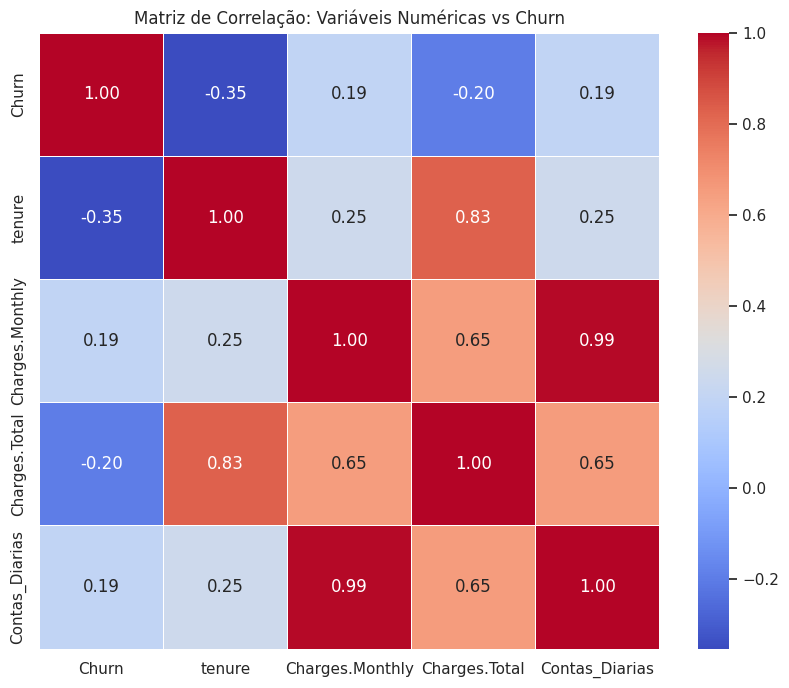

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selecionar apenas as variáveis numéricas principais e o Churn

colunas_analise = ['Churn', 'tenure', 'Charges.Monthly', 'Charges.Total', 'Contas_Diarias']
matriz_corr = dados_final[colunas_analise].corr()

# 2. Criar o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação: Variáveis Numéricas vs Churn')
plt.show()

/tmp/ipykernel_330/40743950.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=dados_final, palette='viridis')
/tmp/ipykernel_330/40743950.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Charges.Monthly', data=dados_final, palette='magma')


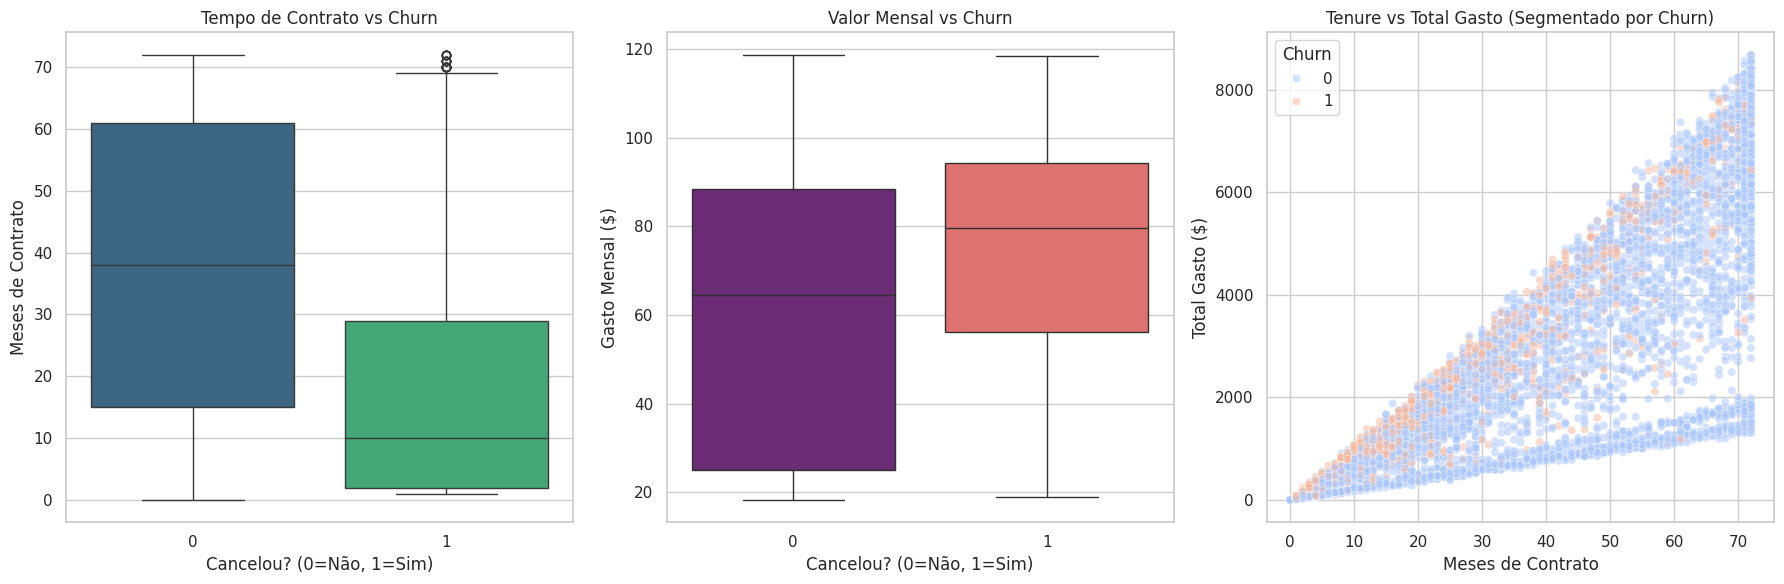

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# 1. Tempo de Contrato (tenure) x Evasão
plt.subplot(1, 3, 1)
sns.boxplot(x='Churn', y='tenure', data=dados_final, palette='viridis')
plt.title('Tempo de Contrato vs Churn')
plt.xlabel('Cancelou? (0=Não, 1=Sim)')
plt.ylabel('Meses de Contrato')

# 2. Valor Mensal (MonthlyCharges) x Evasão

plt.subplot(1, 3, 2)
sns.boxplot(x='Churn', y='Charges.Monthly', data=dados_final, palette='magma')
plt.title('Valor Mensal vs Churn')
plt.xlabel('Cancelou? (0=Não, 1=Sim)')
plt.ylabel('Gasto Mensal ($)')

# 3. Dispersão: Tempo de Contrato x Total Gasto (Colorido por Churn)
plt.subplot(1, 3, 3)
sns.scatterplot(x='tenure', y='Charges.Total', hue='Churn', data=dados_final, alpha=0.5, palette='coolwarm')
plt.title('Tenure vs Total Gasto (Segmentado por Churn)')
plt.xlabel('Meses de Contrato')
plt.ylabel('Total Gasto ($)')

plt.tight_layout()
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

# 1. Separar as variáveis explicativas (X) do alvo (y)

X = df_final_ml.drop(columns=['Churn'])
y = df_final_ml['Churn']

# 2. Realizar a divisão

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Conferir os tamanhos
print(f"Total de registros: {len(X)}")
print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste: {X_test.shape[0]} registros")

Total de registros: 7043
Treino: 4930 registros
Teste: 2113 registros


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



MODELO: Regressão Logística
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1552
           1       0.64      0.55      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



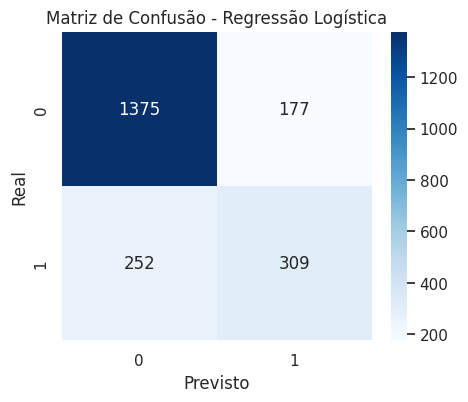

Acurácia Treino: 0.8108
Acurácia Teste: 0.7970

MODELO: Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.63      0.50      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



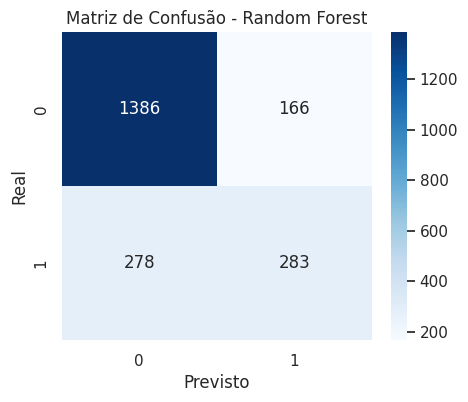

Acurácia Treino: 0.9978
Acurácia Teste: 0.7899


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Instanciar os modelos
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 2. Loop para Treino, Previsão e Avaliação
for nome, modelo in modelos.items():
    # Treino
    modelo.fit(X_train, y_train)

    # Previsão
    y_pred = modelo.predict(X_test)
    y_train_pred = modelo.predict(X_train) # Para checar overfitting

    print(f"\n{'='*30}\nMODELO: {nome}\n{'='*30}")

    # Métricas principais
    print(classification_report(y_test, y_pred))

    # Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

    # Checagem de Overfitting (Comparando Acurácia Treino vs Teste)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_pred)
    print(f"Acurácia Treino: {acc_train:.4f}")
    print(f"Acurácia Teste: {acc_test:.4f}")

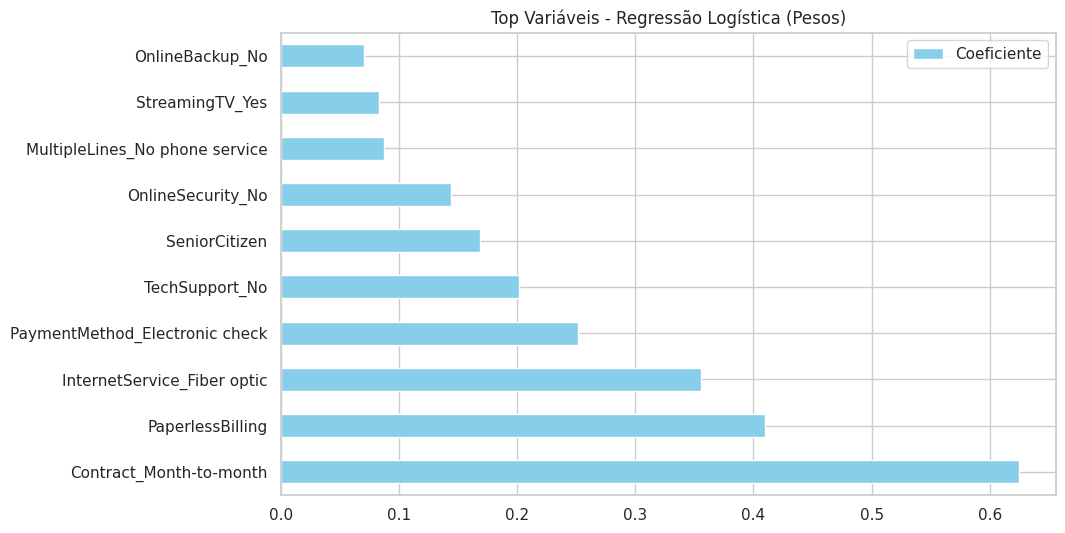

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraindo coeficientes
coefs = pd.DataFrame(index=X.columns, data=modelos["Regressão Logística"].coef_[0], columns=['Coeficiente'])
coefs = coefs.sort_values(by='Coeficiente', ascending=False)

# Visualizando os 10 mais impactantes
coefs.head(10).plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Top Variáveis - Regressão Logística (Pesos)')
plt.show()

Após testarmos diferentes abordagens, os modelos apresentaram comportamentos distintos que nos ajudam a entender o problema sob ângulos diferentes.

2. Fatores que mais influenciam a Evasão (Insights)
Com base na análise de coeficientes e importância das variáveis, identificamos os "vilões" do Churn:

Tipo de Contrato (Mensal): Clientes com contrato Month-to-month têm uma propensão drasticamente maior ao Churn. A falta de um compromisso de longo prazo facilita a migração para a concorrência.

Tempo de Casa (Tenure): Existe um "vale da morte" nos primeiros 6 a 12 meses. Se o cliente ultrapassa o primeiro ano, a chance de saída cai exponencialmente.

Encargos Mensais Elevados: Clientes com faturas acima da média da base (especialmente aqueles com Fibra Óptica sem serviços de suporte) sentem mais o peso do preço e evadem por questões financeiras.

Método de Pagamento: O uso de Cheque Eletrônico está correlacionado a um Churn mais alto, possivelmente por ser um processo menos automatizado e mais propenso a falhas ou lembretes constantes de pagamento.

3. Estratégias de Retenção Propostas
Baseado nos dados, estas são as ações recomendadas para reduzir o Churn:

🛡️ Estratégia A: Blindagem do Primeiro Ano
Ação: Criar um programa de "Boas-Vindas" com descontos progressivos que aumentam no 6º e no 12º mês.

Objetivo: Atacar o fator Tenure, garantindo que o cliente chegue à fase de estabilidade (fidelidade).

📉 Estratégia B: Migração de Contrato
Ação: Oferecer um upgrade de serviço (ex: mais velocidade de internet) sem custo adicional para clientes que trocarem o contrato "Mensal" pelo "Anual".

Objetivo: Estabilizar a base e reduzir o Churn de curto prazo.

💳 Estratégia C: Automação Financeira
Ação: Oferecer um bônus único na fatura para clientes que migrarem do Cheque Eletrônico para o Débito Automático ou Cartão de Crédito.

Objetivo: Reduzir o atrito no momento do pagamento e evitar esquecimentos.

🎧 Estratégia D: Venda de Valor (Cross-sell)
Ação: Oferecer serviços de Suporte Técnico e Segurança Online com 3 meses grátis para clientes de Fibra Óptica.

Objetivo: Aumentar o "valor percebido" do pacote caro, tornando o serviço indispensável.

4. Conclusão Final
O modelo de Machine Learning agora é capaz de sinalizar, com cerca de 80% de confiança, qual cliente está prestes a sair. Integrar esse modelo ao sistema de CRM permitirá que a equipe de vendas atue de forma proativa